In [10]:
import numpy as np
import pandas as pd

file_path = r"C:\Users\npdan\IH_LABS/lab-eda-univariate/amz_uk_price_prediction_dataset.csv"
df = pd.read_csv(file_path)
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [67]:
df.shape

(2443651, 10)

In [73]:
df.nunique()

uid                  2443651
asin                 2222742
title                2077591
stars                     42
reviews                19446
price                  82916
isBestSeller               2
boughtInLastMonth         25
category                 296
log_price              82916
dtype: int64

In [12]:
# **Frequency Tables**:
# Generate the frequency table

frequency_table = df['category'].value_counts().reset_index()
frequency_table.columns = ['Category', 'Frequency']

print(frequency_table)

                                   Category  Frequency
0                         Sports & Outdoors     836265
1                                    Beauty      19312
2    Handmade Clothing, Shoes & Accessories      19229
3                               Bath & Body      19092
4                            Birthday Gifts      18978
..                                      ...        ...
291                  Alexa Built-In Devices        107
292                       Motorbike Chassis        107
293                                   Plugs        107
294          Smart Home Security & Lighting        104
295                          Smart Speakers         54

[296 rows x 2 columns]


In [14]:
# Which are the top 5 most listed product categories?
top_5_categories = df['category'].value_counts().head(5)
print(top_5_categories)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


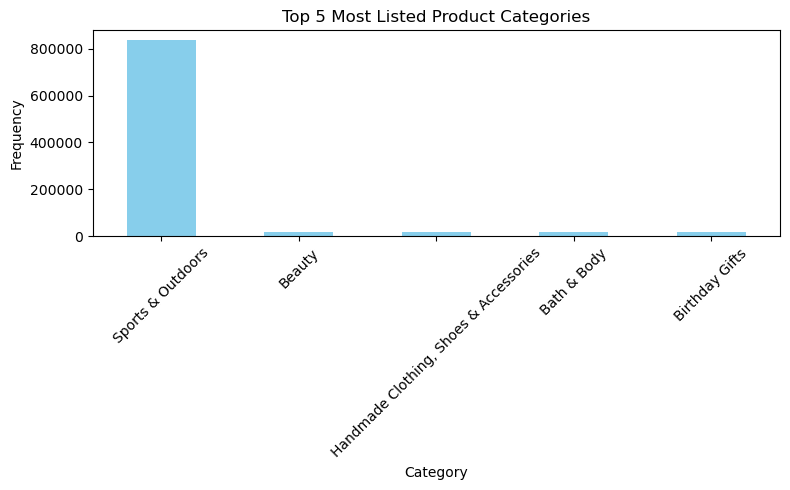

In [16]:
# 2. **Visualizations**:
    # Display the distribution of products across different categories using a bar chart. 
    # If you face problems understanding the chart, do it for a subset of top categories.

import matplotlib.pyplot as plt

# Get the top 5 categories
top_5_categories = df['category'].value_counts().head(5)

# Plotting
plt.figure(figsize=(8, 5))
top_5_categories.plot(kind='bar', color='skyblue')
plt.title('Top 5 Most Listed Product Categories')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Part 2: Delving into Product Pricing
# **Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

In [20]:
#1. **Measures of Centrality**:
   # - Calculate the mean, median, and mode for the `price` of products.

# Mean
mean_price = df['price'].mean()

# Median
median_price = df['price'].median()

# Mode (can return multiple values)
mode_price = df['price'].mode()

print(f"Mean Price: {mean_price}")
print(f"Median Price: {median_price}")
print(f"Mode Price: {mode_price.values}")

Mean Price: 89.24380943923663
Median Price: 19.09
Mode Price: [9.99]


In [75]:
# - What's the average price point of products listed? How does this compare with the most common price point (mode)?
average_price = df['price'].mean()

# average price > mode price

In [32]:
# 2. **Measures of Dispersion**:
   # - Determine the variance, standard deviation, range, and interquartile range for product `price`.

# Standard deviation
standard_deviation_price = df['price'].std()

#Variance
variance_price = df['price'].var()

# Range
price_min = df['price'].min()
price_max = df['price'].max()
price_range = price_max - price_min

# Interquartile Range (IQR)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print (f"Standard deviation is {standard_deviation_price}")
print (f"Variance is {variance_price}")
print(f"Price Range is {price_range} (Min: {price_min}, Max: {price_max})")
print(f"Interquartile Range (IQR) is {IQR} (Q1: {Q1}, Q3: {Q3})")


Standard deviation is 345.60886175352226
Variance is 119445.48532256528
Price Range is 100000.0 (Min: 0.0, Max: 100000.0)
Interquartile Range (IQR) is 36.0 (Q1: 9.99, Q3: 45.99)


In [ ]:
# - How varied are the product prices? Are there any indicators of a significant spread in prices ?
# The price range is very large, from zero to 100k.The variance and the standard deviation are also both very high, which means that the spread is very high. 

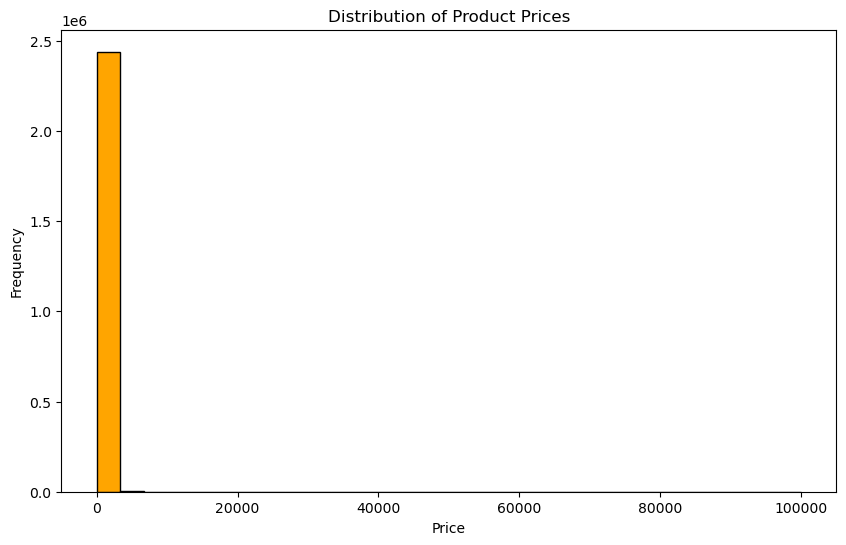

In [40]:
# 3. **Visualizations**:
    # - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices.
    # If its hard to read these diagrams, think why this is, and explain how it could be solved.*

# Histogram 
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, color='orange', edgecolor='black')
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

#The price data is highly skewed (as suggested by a huge range and likely a concentration of values near the lower end), we'll want to transform it so it resembles a normal distribution before visualizing.

Text(0, 0.5, 'Frequency')

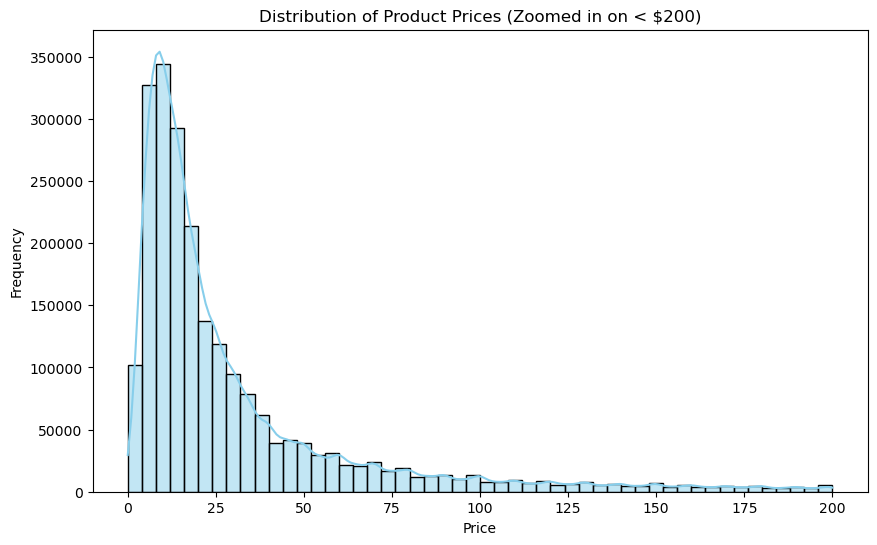

In [79]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['price'] < 200]['price'], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Product Prices (Zoomed in on < $200)')
plt.xlabel('Price')
plt.ylabel('Frequency')

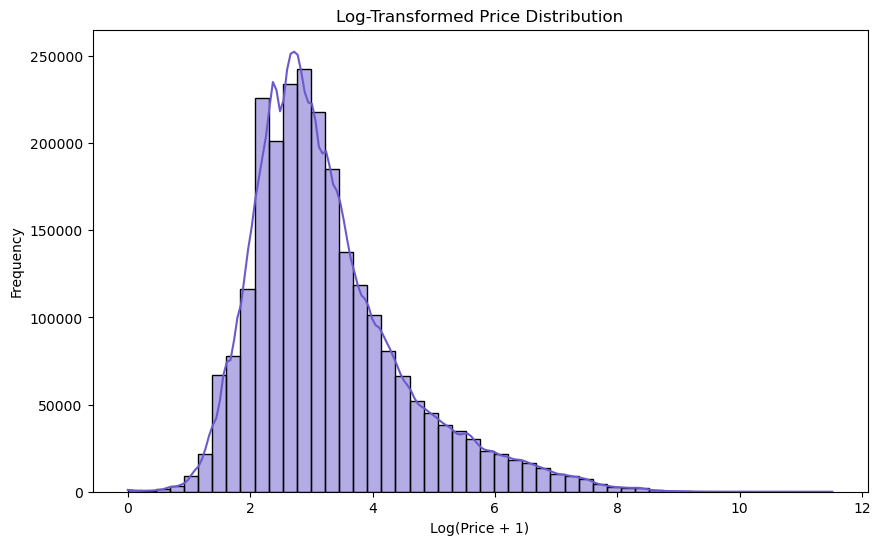

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add a small value to avoid log(0)
df['log_price'] = np.log1p(df['price'])  # log1p(x) = log(1 + x)

# Plot histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(df['log_price'], bins=50, kde=True, color='slateblue')
plt.title('Log-Transformed Price Distribution')
plt.xlabel('Log(Price + 1)')
plt.ylabel('Frequency')
plt.show()

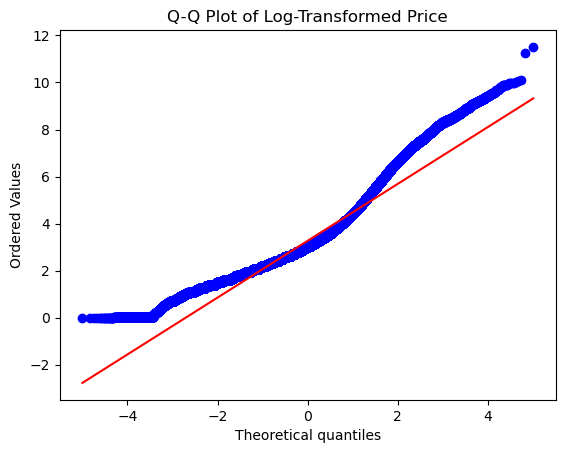

In [44]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['log_price'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Log-Transformed Price")
plt.show()

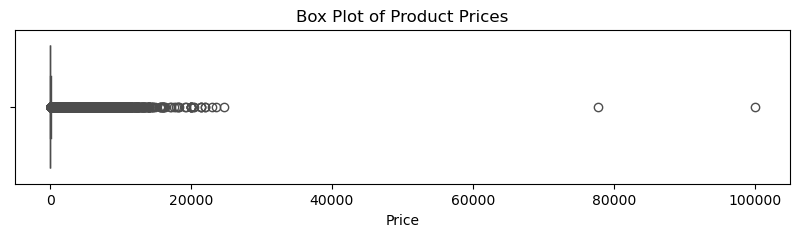

In [48]:
# Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
sns.boxplot(x=df['price'], color='orange')
plt.title('Box Plot of Product Prices')
plt.xlabel('Price')
plt.show()

In [54]:
# Part 3: Unpacking Product Ratings
# **Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

#1. **Measures of Centrality**:
    # - Calculate the mean, median, and mode for the `rating` of products.

# Mean
mean_rating = df['stars'].mean()

# Median
median_rating = df['stars'].median()

# Mode (can return multiple values)
mode_rating = df['stars'].mode()

print(f"Mean rating is {mean_rating}")
print(f"Median rating is {median_rating}")
print(f"Mode rating is {mode_rating}")


Mean rating is 2.152836472966065
Median rating is 0.0
Mode rating is 0    0.0
Name: stars, dtype: float64


In [77]:
#How do customers generally rate products? Is there a common trend?

# Filter rows where stars == 0.0
zero_star_rows = df[df['stars'] == 0.0]

# Display the result
print(zero_star_rows)

# Optional: Count how many rows have stars == 0.0
print(f"Total rows with stars = 0.0: {len(zero_star_rows)}")

             uid        asin  \
25            26  B0BLS36M5R   
90            91  B0BLS4NFP3   
97            98  B07Y4SYSMN   
246          249  B0CD2S45SZ   
254          260  B0CHFG17Q3   
...          ...         ...   
2443641  2828582  B07JM93SCC   
2443645  2828588  B0BQMXJPP5   
2443646  2828589  B0CHSD7P2Q   
2443647  2828590  B0B7B8FNBQ   
2443648  2828591  B0BD5FL5FB   

                                                     title  stars  reviews  \
25       All-new Echo Show 8 | 3rd generation (2023 rel...    0.0        0   
90       All-new Echo Show 8 | 3rd generation (2023 rel...    0.0        0   
97       Fenton Black 5.0 Hi-Fi Home Cinema System Spea...    0.0        0   
246      NEW Bose Smart Ultra Soundbar With Dolby Atmos...    0.0        0   
254      Sonos Move 2, Upgraded inside and out, our mos...    0.0        0   
...                                                    ...    ...      ...   
2443641  Motorcycle Clothing Suit - Motorbike Suit With...    0.0    

In [56]:
# 2. **Measures of Dispersion**:
   # - Determine the variance, standard deviation, and interquartile range for product `rating`.

# Standard deviation
standard_deviation_rating = df['stars'].std()

#Variance
variance_rating = df['stars'].var()

# Interquartile Range (IQR)
Q1 = df['stars'].quantile(0.25)
Q3 = df['stars'].quantile(0.75)
IQR = Q3 - Q1

print (f"Standard deviation is {standard_deviation_rating}")
print (f"Variance is {variance_rating}")
print(f"Interquartile Range (IQR) is {IQR} (Q1: {Q1}, Q3: {Q3})")


Standard deviation is 2.1948653785054697
Variance is 4.81743402976196
Interquartile Range (IQR) is 4.4 (Q1: 0.0, Q3: 4.4)


In [ ]:
  # - Are the ratings consistent, or is there a wide variation in customer feedback?

#The ratings are consistent, the variation is not wide but it isn't narrow neither

In [58]:
# 3. **Shape of the Distribution**:
  #  - Calculate the skewness and kurtosis for the `rating` column. 

# Skewness
skewness = df['stars'].skew()

# Kurtosis
kurtosis = df['stars'].kurt()

print(f"Skewness is {skewness}")
print(f"Kurtosis is {kurtosis}")

Skewness is 0.08120735761080985
Kurtosis is -1.9260061280432985


In [62]:
from scipy.stats import skew, kurtosis

# Drop missing values to avoid errors
rating_clean = df['stars'].dropna()

# Skewness and kurtosis
skewness = skew(rating_clean)
kurt = kurtosis(rating_clean)  # By default, this returns **excess kurtosis** (i.e., kurtosis - 3)

print(f"Skewness: {skewness}")
print(f"Excess Kurtosis: {kurt}")

Skewness: 0.08120730776283354
Excess Kurtosis: -1.926004642549839


In [ ]:
#  - Are the ratings normally distributed, or do they lean towards higher or lower values?
#No, the ratings are not normally distributed, they tend to be very low.

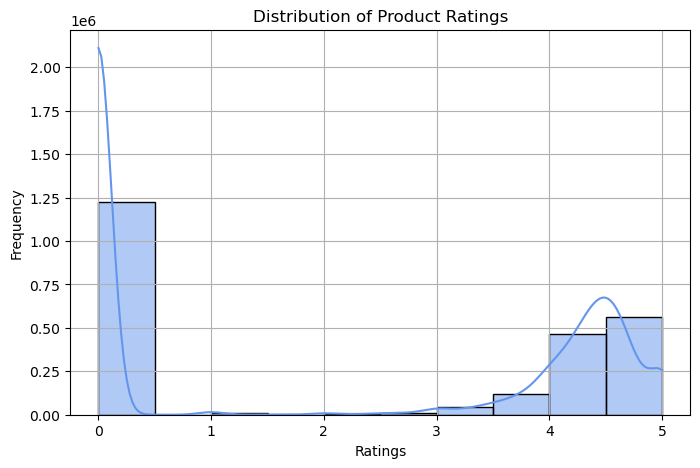

In [65]:
# 4. **Visualizations**:
  #  - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['stars'], bins=10, kde=True, color='cornflowerblue')
plt.title('Distribution of Product Ratings')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
most_common_rating = df['stars'].mode()[0]
print(f"The most common rating is: {most_common_rating}")

In [ ]:
## BUSINESS REPORT

#1- The largest category is Sports & Outdoors with a frequency of 836.265 over 2.222.742, which represents 37,62% of the total.
#2- The price range is very wide. Mean Price: 89.24380943923663 > Median Price: 19.09 > Mode Price: 9.99
#3- The distribution of the prices isn't normal.The Q-Q Plot shows that the distribution line (in blue) is different from the norlal distribution (in red).
#4- There are many products rated 0.0 : 1.225.641 items, which represent more than 55% of the items listed. This has impact on the mean which is very low. It explains why mode and median are equal to zero.

# Conclusions :
# Have relevant actions according to the category, focus on category Sports & Outdoors
# Remove the ratings equal to zero to show higher level of customer satisfaction


In [ ]:
#**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 